In [ ]:
# ============================================
# Blockwise permutation + Areal GP + VI module
# ============================================

import os
from typing import Dict, Any, Sequence

import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

import pandas as pd

# NEW: use SciKit-GStat meuse dataset (no R / rpy2 needed)
try:
    import skgstat as skg
except ImportError:
    skg = None
    print("scikit-gstat not installed. Install with `pip install scikit-gstat` to run meuse demo.")

from GPModel import GPModel
from GPArealModel import GPArealModel
from VIGP_Unlinked import VIGP_Unlinked

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _to_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(x, device=device, dtype=dtype)


# ---------------------------------------------------------
# STEP 2 helper: construct blockwise permutation at data level
# ---------------------------------------------------------

def make_blockwise_permuted_data(
    coords,
    X,
    Y,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
) -> Dict[str, torch.Tensor]:
    """
    Prepare original (restricted) and blockwise-permuted data.

    Inputs
    ------
    coords : array-like (N, d)
    X      : array-like (N,) or (N, 1)
    Y      : array-like (N,)
    n_blocks, n_locations : define N_use = n_blocks * n_locations
    seed : for reproducible permutations

    Returns a dict with:
        coords_orig, X_orig, Y_orig   : restricted, sorted (unpermuted)
        coords_perm, X_perm, Y_perm   : permuted inside blocks
        region_assignments            : (N_use,) with values 0,...,B-1
        perm_matrix_x, perm_matrix_s  : (N_use, N_use) block-diagonal perms
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords = _to_tensor(coords)
    Y = _to_tensor(Y).view(-1)  # (N,)
    X = _to_tensor(X)

    if X.ndim == 1:
        X = X.unsqueeze(1)  # (N, 1)

    N_total = coords.shape[0]
    N_use = n_blocks * n_locations
    if N_total < N_use:
        raise ValueError(f"Not enough locations: N={N_total}, required N_use={N_use}.")

    # Sort by first coordinate, then restrict to N_use
    sort_idx = torch.argsort(coords[:, 0])
    sort_idx = sort_idx[:N_use]

    coords_orig = coords[sort_idx].contiguous()  # (N_use, d)
    X_orig = X[sort_idx].contiguous()            # (N_use, 1)
    Y_orig = Y[sort_idx].contiguous()            # (N_use,)

    N = N_use

    # Region assignments: fixed blocks
    region_assignments = torch.zeros(N, dtype=torch.long, device=device)
    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        region_assignments[start:end] = b

    # Blockwise permutation matrices
    #   - perm_matrix_x: permutes X,Y jointly within block
    #   - perm_matrix_s: independent perm for coordinates
    perm_matrix_x = torch.zeros(N, N, device=device)
    perm_matrix_s = torch.zeros(N, N, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations

        # X,Y permutation
        perm_xy = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_x[start + i, start + perm_xy[i]] = 1.0

        # S permutation
        perm_s = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_s[start + i, start + perm_s[i]] = 1.0

    # Apply permutations
    Y_perm = (perm_matrix_x @ Y_orig.view(N, 1)).view(N)
    X_perm = perm_matrix_x @ X_orig                  # (N, 1)
    coords_perm = perm_matrix_s @ coords_orig        # (N, d)

    return {
        "coords_orig": coords_orig,
        "X_orig": X_orig,
        "Y_orig": Y_orig,
        "coords_perm": coords_perm,
        "X_perm": X_perm,
        "Y_perm": Y_perm,
        "region_assignments": region_assignments,
        "perm_matrix_x": perm_matrix_x,
        "perm_matrix_s": perm_matrix_s,
    }


# ---------------------------------------------------------
# NEW: STEP 3a helper: Areal GP **only**
# ---------------------------------------------------------

def run_areal_gp(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    region_assignments: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_GPAreal: int = 3000,
) -> Dict[str, Any]:
    """
    Run GPArealModel (areal GP) on block-averaged data,
    using permuted coordinates and block structure.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"GPArealModel wrapper assumes scalar X (p=1), got p={p}.")

    region_assignments = region_assignments.to(device=device, dtype=torch.long)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Block averages of X and Y
    ybar = torch.zeros(n_blocks, device=device)
    xbar = torch.zeros(n_blocks, p, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        idx = torch.arange(start, end, device=device)
        ybar[b] = Y_perm[idx].mean()
        xbar[b] = X_perm[idx].mean(dim=0)

    gpa = GPArealModel().to(device)
    opt_gpa = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)

    for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel (areal)"):
        opt_gpa.zero_grad()
        loss = gpa(coords_perm, region_assignments, xbar, ybar)
        loss.backward()
        opt_gpa.step()
        with torch.no_grad():
            gpa.sigmasq.clamp_(min=1e-6)
            gpa.phi.clamp_(min=1e-6)
            gpa.tausq.clamp_(min=1e-6)

    return {
        "nu": float(gpa.nu.item()),
        "phi": float(gpa.phi.item()),
        "sigmasq": float(gpa.sigmasq.item()),
        "tausq": float(gpa.tausq.item()),
        "beta": gpa.beta.detach().cpu().numpy(),
    }


# ---------------------------------------------------------
# NEW: STEP 3b helper: VI for Unlinked GP **only**
# ---------------------------------------------------------

def run_vi_unlinked(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    perm_matrix_x: torch.Tensor,
    perm_matrix_s: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_VI: int = 100,
    tau_grid: Sequence[float] = (0.2, 0.4, 0.6, 0.8, 0.9),
) -> Dict[str, Any]:
    """
    Run VIGP_Unlinked (VI for unlinked GP) on blockwise permuted X,Y,S.

    Returns a dict with VI outputs for each tau:
        {
          "by_tau": { tau_value: vi_out, ... },
          "taus": [...],
          "prior_parameters": {...}      # for reference
        }
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)  # (N,)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"VI wrapper assumes scalar X (p=1), got p={p}.")

    perm_matrix_x = perm_matrix_x.to(device=device)
    perm_matrix_s = perm_matrix_s.to(device=device)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Distances from permuted coordinates
    Dist = torch.cdist(coords_perm, coords_perm, p=2)
    Dist = (Dist + Dist.T) / 2.0

    # Block-shaped tensors for VI
    X_blocks = X_perm.view(n_blocks, n_locations)  # (B, n_i)
    Y_blocks = Y_perm.view(n_blocks, n_locations)  # (B, n_i)

    n_steps = 50
    n_phi_samples = 100
    n_piX_sample = 50
    n_piS_sample = 50

    prior_parameters = {
        "a1": 0.1,
        "b1": 0.1,
        "a2": 0.1,
        "b2": 0.1,
        "eta_X_sq": 0.1,
        "eta_S_sq": 0.1,
        "mu_beta": 0.0,
        "sigmasq_beta": 100.0,
        "phi_prior_lb": (1.0 / torch.max(Dist)),
        "phi_prior_ub": 10.0,
    }

    # Precompute mean_Rphi_inv_fixed at some phi (e.g., 4)
    Rphi = torch.exp(-4.0 * Dist)
    mean_Rphi_inv_fixed = torch.linalg.inv(Rphi + 1e-6 * torch.eye(N, device=device))

    vi_results_by_tau: Dict[float, Any] = {}

    for tau in tau_grid:
        vi_out = VIGP_Unlinked(
            n_iter=niter_VI,
            n_blocks=n_blocks,
            n_locations=n_locations,
            X=X_blocks,
            Y=Y_blocks,
            Dist=Dist,
            n_steps=n_steps,
            n_phi_samples=n_phi_samples,
            n_piX_sample=n_piX_sample,
            tau_X=tau,
            tau_S=tau,
            n_piS_sample=n_piS_sample,
            seed=seed,
            fix_piX=False,
            fix_piS=False,
            fix_mu_lambda_beta=False,
            fix_sigmasq_lambda_beta=False,
            fix_lambda_b1=False,
            lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
            fix_lambda_b2=False,
            M_X_star_fixed=perm_matrix_x.T,
            M_S_star_fixed=perm_matrix_s.T,
            V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
            V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
            phi_init=0.5,
            mean_Rphi_inv_fixed=mean_Rphi_inv_fixed,
            fix_mean_Rphi_inv=False,
            pi_X_true=perm_matrix_x.T,
            pi_S_true=perm_matrix_s.T,
            VX_ub=0.5,
            VS_ub=0.5,
            lr_piS=0.01,
            lr_piX=0.01,
            prior_parameters=prior_parameters,
        )
        vi_results_by_tau[float(tau)] = vi_out

    return {
        "by_tau": vi_results_by_tau,
        "taus": list(map(float, tau_grid)),
        "prior_parameters": prior_parameters,
    }


# ============================================================
# Demo: FULL PIPELINE on meuse (SciKit-GStat)
# ============================================================


# -----------------------------
# STEP 1: get data (meuse via SciKit-GStat)
# -----------------------------
src = skg.data.meuse()
# This returns coordinates (x,y) and lead values by default
coords_meuse, vals_meuse = src.get('sample')  # coords: (N, 2), vals: (N, 1)

# Use heavy metal measurement as response (log-transform)
Y_meuse = np.log1p(vals_meuse.flatten())

# For a simple scalar covariate X, we can use x-coordinate as a toy covariate
# (You can replace this with any 1D function of coords or external covariate)
X_meuse = coords_meuse[:, 0]  # shape (N,)

N_meuse = coords_meuse.shape[0]
print(f"Loaded meuse from SciKit-GStat: N = {N_meuse}")

# Choose block design
n_blocks_demo = 25
n_locations_demo = 6
N_use_demo = n_blocks_demo * n_locations_demo
if N_meuse < N_use_demo:
    raise ValueError(f"Meuse has {N_meuse} rows; reduce blocks or n_locations.")

# -----------------------------
# STEP 2: create permuted data
# -----------------------------
prep = make_blockwise_permuted_data(
    coords=coords_meuse,
    X=X_meuse,
    Y=Y_meuse,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
)

coords_orig = prep["coords_orig"]
X_orig = prep["X_orig"]
Y_orig = prep["Y_orig"]

coords_perm = prep["coords_perm"]
X_perm = prep["X_perm"]
Y_perm = prep["Y_perm"]
region_assignments = prep["region_assignments"]
perm_matrix_x = prep["perm_matrix_x"]
perm_matrix_s = prep["perm_matrix_s"]

# -----------------------------
# STEP 3a: Areal GP on permuted data
# -----------------------------
areal_results = run_areal_gp(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    region_assignments=region_assignments,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
    niter_GPAreal=800,   # shorter for demo
)

# -----------------------------
# STEP 3b: VI unlinked on permuted data
# -----------------------------
vi_results = run_vi_unlinked(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    perm_matrix_x=perm_matrix_x,
    perm_matrix_s=perm_matrix_s,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
    niter_VI=50,
    tau_grid=(0.3, 0.5, 0.7),
)

# -----------------------------
# STEP 4: Oracle GP on original data
# -----------------------------
gp_oracle = GPModel().to(device)
opt_gp = optim.AdamW(gp_oracle.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(800), desc="Train GPModel (oracle, meuse)"):
    opt_gp.zero_grad()
    loss = gp_oracle(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp.step()
    with torch.no_grad():
        gp_oracle.sigmasq.clamp_(min=1e-6)
        gp_oracle.phi.clamp_(min=1e-6)
        gp_oracle.tausq.clamp_(min=1e-6)

oracle_params = {
    "nu": float(gp_oracle.nu.item()),
    "phi": float(gp_oracle.phi.item()),
    "sigmasq": float(gp_oracle.sigmasq.item()),
    "tausq": float(gp_oracle.tausq.item()),
    "beta": gp_oracle.beta.detach().cpu().numpy(),
}

# -----------------------------
# STEP 5: Compare results (simple print)
# -----------------------------
print("\n=== Oracle GP (original data) ===")
print(oracle_params)

print("\n=== Areal GP (permuted data) ===")
print(areal_results)

print("\n=== VI (unlinked) taus tried ===")
print(vi_results["taus"])
# You can inspect vi_results["by_tau"][tau] for detailed VI output per tau.


Loaded meuse from SciKit-GStat: N = 155


Train GPArealModel (areal):  38%|███▊      | 303/800 [00:00<00:00, 1660.88it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -1.3007e-07
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -1.3007e-07


  0%|          | 0/50 [00:16<?, ?it/s]

Iter 1/50 | mu_lambda_beta: 0.0000 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 75.1000 | lambda_b1: 17479160.0000 | lambda_a2: 75.1000 | lambda_b2: 108.7145
‣  E[ϕ]: nan | ‣ ||mu_W||: 3.4060


RuntimeError: The size of tensor a (6) must match the size of tensor b (150) at non-singleton dimension 1

In [7]:
src

{'sample': (array([[181072, 333611],
         [181025, 333558],
         [181165, 333537],
         [181298, 333484],
         [181307, 333330],
         [181390, 333260],
         [181165, 333370],
         [181027, 333363],
         [181060, 333231],
         [181232, 333168],
         [181191, 333115],
         [181032, 333031],
         [180874, 333339],
         [180969, 333252],
         [181011, 333161],
         [180830, 333246],
         [180763, 333104],
         [180694, 332972],
         [180625, 332847],
         [180555, 332707],
         [180642, 332708],
         [180704, 332717],
         [180704, 332664],
         [181153, 332925],
         [181147, 332823],
         [181167, 332778],
         [181008, 332777],
         [180973, 332687],
         [180916, 332753],
         [181352, 332946],
         [181133, 332570],
         [180878, 332489],
         [180829, 332450],
         [180954, 332399],
         [180956, 332318],
         [180710, 332330],
         [180632, 

In [3]:
# ============================================
# Blockwise permutation + Areal GP + VI module
# Using meuse_obs.zip (geopandas) & elev as X
# ============================================

import os
from typing import Dict, Any, Sequence

import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm

import pandas as pd
import geopandas as gpd  # <--- NEW

from GPModel import GPModel
from GPArealModel import GPArealModel
from VIGP_Unlinked import VIGP_Unlinked

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _to_tensor(x, dtype=torch.float32):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=dtype)
    return torch.as_tensor(x, device=device, dtype=dtype)


# ---------------------------------------------------------
# STEP 2 helper: construct blockwise permutation at data level
# ---------------------------------------------------------

def make_blockwise_permuted_data(
    coords,
    X,
    Y,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
) -> Dict[str, torch.Tensor]:
    """
    Prepare original (restricted) and blockwise-permuted data.

    Inputs
    ------
    coords : array-like (N, d)
    X      : array-like (N,) or (N, 1)
    Y      : array-like (N,)
    n_blocks, n_locations : define N_use = n_blocks * n_locations
    seed : for reproducible permutations

    Returns a dict with:
        coords_orig, X_orig, Y_orig   : restricted, sorted (unpermuted)
        coords_perm, X_perm, Y_perm   : permuted inside blocks
        region_assignments            : (N_use,) with values 0,...,B-1
        perm_matrix_x, perm_matrix_s  : (N_use, N_use) block-diagonal perms
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords = _to_tensor(coords)
    Y = _to_tensor(Y).view(-1)  # (N,)
    X = _to_tensor(X)

    if X.ndim == 1:
        X = X.unsqueeze(1)  # (N, 1)

    N_total = coords.shape[0]
    N_use = n_blocks * n_locations
    if N_total < N_use:
        raise ValueError(f"Not enough locations: N={N_total}, required N_use={N_use}.")

    # Sort by first coordinate (x), then restrict to N_use
    sort_idx = torch.argsort(coords[:, 0])
    sort_idx = sort_idx[:N_use]

    coords_orig = coords[sort_idx].contiguous()  # (N_use, d)
    X_orig = X[sort_idx].contiguous()            # (N_use, 1)
    Y_orig = Y[sort_idx].contiguous()            # (N_use,)

    N = N_use

    # Region assignments: fixed blocks
    region_assignments = torch.zeros(N, dtype=torch.long, device=device)
    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        region_assignments[start:end] = b

    # Blockwise permutation matrices
    #   - perm_matrix_x: permutes X,Y jointly within block
    #   - perm_matrix_s: independent perm for coordinates
    perm_matrix_x = torch.zeros(N, N, device=device)
    perm_matrix_s = torch.zeros(N, N, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations

        # X,Y permutation
        perm_xy = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_x[start + i, start + perm_xy[i]] = 1.0

        # S permutation
        perm_s = torch.randperm(n_locations, device=device)
        for i in range(n_locations):
            perm_matrix_s[start + i, start + perm_s[i]] = 1.0

    # Apply permutations
    Y_perm = (perm_matrix_x @ Y_orig.view(N, 1)).view(N)
    X_perm = perm_matrix_x @ X_orig                  # (N, 1)
    coords_perm = perm_matrix_s @ coords_orig        # (N, d)

    return {
        "coords_orig": coords_orig,
        "X_orig": X_orig,
        "Y_orig": Y_orig,
        "coords_perm": coords_perm,
        "X_perm": X_perm,
        "Y_perm": Y_perm,
        "region_assignments": region_assignments,
        "perm_matrix_x": perm_matrix_x,
        "perm_matrix_s": perm_matrix_s,
    }


# ---------------------------------------------------------
# STEP 3a: Areal GP ONLY (disentangled)
# ---------------------------------------------------------

def run_areal_gp(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    region_assignments: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_GPAreal: int = 3000,
) -> Dict[str, Any]:
    """
    Run GPArealModel (areal GP) on block-averaged data,
    using permuted coordinates and block structure.
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"GPArealModel wrapper assumes scalar X (p=1), got p={p}.")

    region_assignments = region_assignments.to(device=device, dtype=torch.long)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Block averages of X and Y
    ybar = torch.zeros(n_blocks, device=device)
    xbar = torch.zeros(n_blocks, p, device=device)

    for b in range(n_blocks):
        start = b * n_locations
        end = (b + 1) * n_locations
        idx = torch.arange(start, end, device=device)
        ybar[b] = Y_perm[idx].mean()
        xbar[b] = X_perm[idx].mean(dim=0)

    gpa = GPArealModel().to(device)
    opt_gpa = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)

    for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel (areal)"):
        opt_gpa.zero_grad()
        loss = gpa(coords_perm, region_assignments, xbar, ybar)
        loss.backward()
        opt_gpa.step()
        with torch.no_grad():
            gpa.sigmasq.clamp_(min=1e-6)
            gpa.phi.clamp_(min=1e-6)
            gpa.tausq.clamp_(min=1e-6)

    return {
        "nu": float(gpa.nu.item()),
        "phi": float(gpa.phi.item()),
        "sigmasq": float(gpa.sigmasq.item()),
        "tausq": float(gpa.tausq.item()),
        "beta": gpa.beta.detach().cpu().numpy(),
    }


# ---------------------------------------------------------
# STEP 3b: VI for Unlinked GP ONLY (disentangled)
# ---------------------------------------------------------

def run_vi_unlinked(
    coords_perm: torch.Tensor,
    X_perm: torch.Tensor,
    Y_perm: torch.Tensor,
    perm_matrix_x: torch.Tensor,
    perm_matrix_s: torch.Tensor,
    n_blocks: int,
    n_locations: int,
    seed: int = 521,
    niter_VI: int = 100,
    tau_grid: Sequence[float] = (0.2, 0.4, 0.6, 0.8, 0.9),
) -> Dict[str, Any]:
    """
    Run VIGP_Unlinked (VI for unlinked GP) on blockwise permuted X,Y,S.

    Returns a dict with VI outputs for each tau:
        {
          "by_tau": { tau_value: vi_out, ... },
          "taus": [...],
          "prior_parameters": {...}
        }
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    coords_perm = _to_tensor(coords_perm)
    Y_perm = _to_tensor(Y_perm).view(-1)  # (N,)
    X_perm = _to_tensor(X_perm)

    if X_perm.ndim == 1:
        X_perm = X_perm.unsqueeze(1)
    p = X_perm.shape[1]
    if p != 1:
        raise ValueError(f"VI wrapper assumes scalar X (p=1), got p={p}.")

    perm_matrix_x = perm_matrix_x.to(device=device)
    perm_matrix_s = perm_matrix_s.to(device=device)

    N = coords_perm.shape[0]
    assert N == n_blocks * n_locations, "N must equal n_blocks * n_locations."

    # Distances from permuted coordinates
    Dist = torch.cdist(coords_perm, coords_perm, p=2)
    Dist = (Dist + Dist.T) / 2.0

    # Block-shaped tensors for VI
    X_blocks = X_perm.view(n_blocks, n_locations)  # (B, n_i)
    Y_blocks = Y_perm.view(n_blocks, n_locations)  # (B, n_i)

    n_steps = 50
    n_phi_samples = 100
    n_piX_sample = 50
    n_piS_sample = 50

    prior_parameters = {
        "a1": 0.1,
        "b1": 0.1,
        "a2": 0.1,
        "b2": 0.1,
        "eta_X_sq": 0.1,
        "eta_S_sq": 0.1,
        "mu_beta": 0.0,
        "sigmasq_beta": 100.0,
        "phi_prior_lb": (1.0 / torch.max(Dist)),
        "phi_prior_ub": 10.0,
    }

    # Precompute mean_Rphi_inv_fixed at some phi (e.g., 4)
    Rphi = torch.exp(-4.0 * Dist)
    mean_Rphi_inv_fixed = torch.linalg.inv(Rphi + 1e-6 * torch.eye(N, device=device))

    vi_results_by_tau: Dict[float, Any] = {}

    for tau in tau_grid:
        vi_out = VIGP_Unlinked(
            n_iter=niter_VI,
            n_blocks=n_blocks,
            n_locations=n_locations,
            X=X_blocks,
            Y=Y_blocks,
            Dist=Dist,
            n_steps=n_steps,
            n_phi_samples=n_phi_samples,
            n_piX_sample=n_piX_sample,
            tau_X=tau,
            tau_S=tau,
            n_piS_sample=n_piS_sample,
            seed=seed,
            fix_piX=False,
            fix_piS=False,
            fix_mu_lambda_beta=False,
            fix_sigmasq_lambda_beta=False,
            fix_lambda_b1=False,
            lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
            fix_lambda_b2=False,
            M_X_star_fixed=perm_matrix_x.T,
            M_S_star_fixed=perm_matrix_s.T,
            V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
            V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
            phi_init=0.5,
            mean_Rphi_inv_fixed=mean_Rphi_inv_fixed,
            fix_mean_Rphi_inv=False,
            pi_X_true=perm_matrix_x.T,
            pi_S_true=perm_matrix_s.T,
            VX_ub=0.5,
            VS_ub=0.5,
            lr_piS=0.01,
            lr_piX=0.01,
            prior_parameters=prior_parameters,
        )
        vi_results_by_tau[float(tau)] = vi_out

    return {
        "by_tau": vi_results_by_tau,
        "taus": list(map(float, tau_grid)),
        "prior_parameters": prior_parameters,
    }


# ============================================================
# Demo: FULL PIPELINE on meuse_obs.zip
# ============================================================


# __file__ is not defined in interactive environments (e.g., Jupyter notebooks).
# Fall back to the current working directory when needed.
try:
    base_dir = os.path.dirname(__file__)
except NameError:
    base_dir = os.getcwd()

MEUSE_OBS_PATH = os.path.abspath(os.path.join(
    base_dir,
    "..",
    "data", "data_analysis",
    "meuse_obs.zip",
))

meuse_obs = gpd.read_file(MEUSE_OBS_PATH)

# coords from geometry (x, y)
coords_meuse = np.column_stack(
    [meuse_obs.geometry.x.to_numpy(), meuse_obs.geometry.y.to_numpy()]
)

# response: log1p(zinc)
Y_meuse = np.log1p(meuse_obs["zinc"].to_numpy())

# scalar covariate: elevation
# (column name in this dataset is 'elev'; if it's 'elevation' on your side, change here)
X_meuse = meuse_obs["elev"].to_numpy()

N_meuse = coords_meuse.shape[0]
print(f"Loaded meuse_obs: N = {N_meuse}")


Loaded meuse_obs: N = 155


In [5]:


# Choose block design
n_blocks_demo = 31
n_locations_demo = 5
N_use_demo = n_blocks_demo * n_locations_demo
if N_meuse < N_use_demo:
    raise ValueError(f"Meuse has {N_meuse} rows; reduce blocks or n_locations.")

# -----------------------------
# STEP 2: create permuted data
# -----------------------------
prep = make_blockwise_permuted_data(
    coords=coords_meuse,
    X=X_meuse,
    Y=Y_meuse,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
)

coords_orig = prep["coords_orig"]
X_orig = prep["X_orig"]
Y_orig = prep["Y_orig"]

coords_perm = prep["coords_perm"]
X_perm = prep["X_perm"]
Y_perm = prep["Y_perm"]
region_assignments = prep["region_assignments"]
perm_matrix_x = prep["perm_matrix_x"]
perm_matrix_s = prep["perm_matrix_s"]


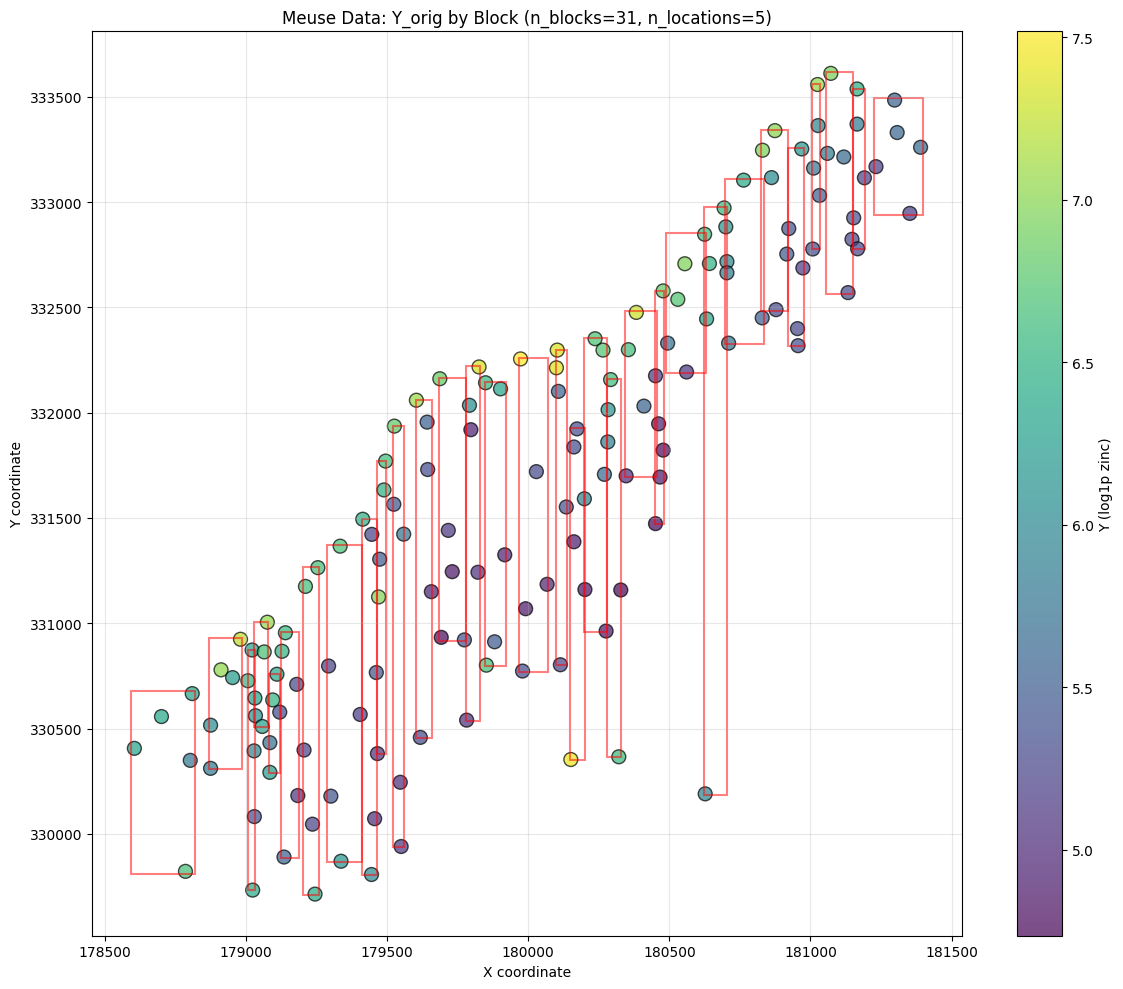

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Extract coordinates and reshape by blocks
N = coords_orig.shape[0]
coords_np = coords_orig.cpu().numpy()
Y_np = Y_orig.cpu().numpy()
regions_np = region_assignments.cpu().numpy()

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Scatter plot of Y_orig colored by region
scatter = ax.scatter(coords_np[:, 0], coords_np[:, 1], c=Y_np, s=100, 
                     cmap='viridis', edgecolors='black', alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax, label='Y (log1p zinc)')

# Add block boundaries
for b in range(n_blocks_demo):
    start = b * n_locations_demo
    end = (b + 1) * n_locations_demo
    block_coords = coords_np[start:end]
    
    # Compute bounding box for this block
    x_min, y_min = block_coords.min(axis=0)
    x_max, y_max = block_coords.max(axis=0)
    
    # Add small margin for visualization
    margin = (x_max - x_min) * 0.05
    rect = patches.Rectangle((x_min - margin, y_min - margin), 
                              (x_max - x_min) + 2*margin, 
                              (y_max - y_min) + 2*margin,
                              linewidth=1.5, edgecolor='red', 
                              facecolor='none', alpha=0.5)
    ax.add_patch(rect)

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Meuse Data: Y_orig by Block (n_blocks={n_blocks_demo}, n_locations={n_locations_demo})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:


# -----------------------------
# STEP 3a: Areal GP on permuted data
# -----------------------------
areal_results = run_areal_gp(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    region_assignments=region_assignments,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2030,
    niter_GPAreal=1000,   # shorter for demo
)


Train GPArealModel (areal): 100%|██████████| 1000/1000 [00:00<00:00, 2177.13it/s]


In [15]:
areal_results

{'nu': 0.5,
 'phi': 0.4524090886116028,
 'sigmasq': 1.6565525531768799,
 'tausq': 0.5440145134925842,
 'beta': array([0.70769316], dtype=float32)}

In [ ]:
# -----------------------------
# STEP 3b: VI unlinked on permuted data
# -----------------------------
vi_results = run_vi_unlinked(
    coords_perm=coords_perm,
    X_perm=X_perm,
    Y_perm=Y_perm,
    perm_matrix_x=perm_matrix_x,
    perm_matrix_s=perm_matrix_s,
    n_blocks=n_blocks_demo,
    n_locations=n_locations_demo,
    seed=2025,
    niter_VI=50,
    tau_grid=(0.1, 0.3, 0.5, 0.7),
)


  0%|          | 0/50 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -9.5963e-08
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -9.5963e-08


  0%|          | 0/50 [00:16<?, ?it/s]

Iter 1/50 | mu_lambda_beta: 0.7079 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 77.6000 | lambda_b1: 19094276.0000 | lambda_a2: 77.6000 | lambda_b2: 172.9947
‣  E[ϕ]: nan | ‣ ||mu_W||: 7.4261


RuntimeError: The size of tensor a (5) must match the size of tensor b (155) at non-singleton dimension 1

In [10]:


# -----------------------------
# STEP 4: Oracle GP on original data
# -----------------------------
gp_oracle = GPModel().to(device)
opt_gp = optim.AdamW(gp_oracle.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(800), desc="Train GPModel (oracle, meuse)"):
    opt_gp.zero_grad()
    loss = gp_oracle(coords_orig, X_orig, Y_orig)
    loss.backward()
    opt_gp.step()
    with torch.no_grad():
        gp_oracle.sigmasq.clamp_(min=1e-6)
        gp_oracle.phi.clamp_(min=1e-6)
        gp_oracle.tausq.clamp_(min=1e-6)

oracle_params = {
    "nu": float(gp_oracle.nu.item()),
    "phi": float(gp_oracle.phi.item()),
    "sigmasq": float(gp_oracle.sigmasq.item()),
    "tausq": float(gp_oracle.tausq.item()),
    "beta": gp_oracle.beta.detach().cpu().numpy(),
}


Train GPModel (oracle, meuse): 100%|██████████| 800/800 [00:00<00:00, 2059.58it/s]


In [ ]:

# -----------------------------
# STEP 5: Compare results
# -----------------------------
print("\n=== Oracle GP (original data) ===")
print(oracle_params)

print("\n=== Areal GP (permuted data) ===")
print(areal_results)

print("\n=== VI (unlinked) taus tried ===")
print(vi_results["taus"])
# Detailed VI output: vi_results["by_tau"][0.3], etc.
